## 0. Import Python Libraries

An essential first step . . .


In [1]:
# crim intervals
import crim_intervals
import crim_intervals.visualizations as viz
import crim_intervals.corpus_tools as corpus_tools
from crim_intervals import CorpusBase, ImportedPiece, importScore
from crim_intervals.corpus_tools import corpus_notes, corpus_mel

# standard library
import glob
import os
import re
import warnings
from copy import deepcopy

# data analysis
import pandas as pd
from itertools import combinations

# visualization
import altair as alt
import plotly.express as px
import plotly.io as pio

# network analysis
import networkx as nx
from community import community_louvain

from pyvis.network import Network

# create directories if needed
for dir_name in ('saved_csv', 'MEI'):
    if not os.path.isdir(dir_name):
        os.makedirs(dir_name)

# configure plotting for Quarto
alt.renderers.enable('default')
pio.renderers.default = "plotly_mimetype+notebook_connected"

# suppress warnings
warnings.filterwarnings('ignore')


### 0.1 Helper Functions and Sorting List

- These will help us sort and regularize note names

In [2]:
# DO NOT EDIT!

# sorting intervals
def extract_descending(interval):
    match = re.search(r'-?\d+', interval)
    return int(match.group())

def extract_and_sort_reverse(items):
    # Function to extract numeric part
    def extract_num(item):
        match = re.search(r'[-+]?\d+', item)
        return int(match.group()) if match else 0
    
    # Extract numbers and sort
    sorted_neg_items = sorted(items, key=extract_num, reverse=True)
    return sorted_neg_items

def extract_and_sort_forward(items):
    # Function to extract numeric part
    def extract_num(item):
        match = re.search(r'[-+]?\d+', item)
        return int(match.group()) if match else 0
    
    # Extract numbers and sort
    sorted_items = sorted(items, key=extract_num, reverse=False)  
    return sorted_items


# set the custom order for pitches
pitch_order = ['Rest',
               'A#1', 'B1', 
               'C2', 'C#2', 'D2', 'D#2','E-2', 'E2', 'E#2', 'F2', 'F#2', 'G-2', 'G2', 'G#2', 'A-2', 'A2', 'A#2','B-2', 'B2', 'B#2',
               'C3', 'C#3', 'D-3','D3', 'D#3', 'E-3','E3', 'E#3', 'F3', 'F#3', 'G-3', 'F##3', 'G3', 'G#3', 'A-3', 'A3', 'A#3', 'B-3','B3', 'B#3',
               'C4', 'C#4', 'D-4','D4', 'D#4','E-4', 'E4', 'F-4', 'E#4', 'F4', 'F#4', 'G-4', 'F##4', 'G4', 'G#4', 'A-4','A4', 'A#4', 'B-4', 'B4', 'B#4',
               'C5', 'C#5','C##5', 'D-5','D5', 'D#5', 'E-5','E5', 'F-5','E#5','F5', 'F#5', 'G-5', 'F##5','G5', 'G#5', 'A-5', 'A5', 'A#5', 'B-5', 'B5',
              'C6']

chromatic = ['C', 'C#', 'Db','D', 'D#', 'Eb', 'E', 'Fb', 'E#', 'F', 'F#', 'Gb', 'F##', 'G', 'G#', 'Ab','A', 'A#', 'Bb', 'B', 'B#']

fifths = [
    'C', 'B#',           # I
    'G',                 # V
    'D',                 # II
    'A',                 # VI
    'E', 'Fb',           # III
    'B', 'Cb',           # VII
    'F#', 'Gb',          # IV#/bV
    'C#', 'Db',          # bII
    'G#', 'Ab',          # bVI
    'D#', 'Eb',          # bIII
    'A#', 'Bb',          # bVII
    'F', 'E#',           # IV
    'F##'                # (enharmonic G, if present)
]

# 1. Introduction:  All About CRIM Intervals

In this Notebook we will explore our contrapuntal duos with **CRIM Intervals**, a Python library developed especially for the purpose of analyzing 'contrapuntal' music like the duos we have been considering lately. It leverages the power of  Mike Cuthbert's excellent Python library [music21](https://web.mit.edu/music21/) (which takes care of all the headaches of finding notes and intervals), but brings the results into Pandas, and thus allows us to turn scores into tablular data.  Learn more about [CRIM Intervals](https://github.com/HCDigitalScholarship/intervals).

### Notes and Durations
- **piece.notes()**, which finds all the notes and rests in a score, with a tabular score-like representation of the pitches, pitch classes, and durations (expressed in music21 "offsets", in which each quarter note corresponds to the value of 1.0). It can also derminte the location of any note as a measure+beat reference with piece.detailIndex()
- **piece.durations()**, with quarter-note = 1.0, as per music21.  

Learn more about [notes](https://github.com/HCDigitalScholarship/intervals/blob/main/tutorial/02_Notes_Rests.md) and about [durations](https://github.com/HCDigitalScholarship/intervals/blob/main/tutorial/03_Durations.md)

### Melodic and Harmonic Intervals
- **piece.melodic()**, which finds melodic intervals in any voice part, with various options for diatonic, chromatic and zero-based distances. Intervals can be compound (distinguishing between tenths and thirds, for instance), or simple, and can include quality (distinguishing major and minor thirds, for instance), or not.
- **piece.harmonic()**, which finds harmonic intervals between every combination of two voices in a piece, with various options for diatonic and chromatic. These intervals can also be directed (as when a tenor voice sounds above the altus), or not.

Learn more [melodic intervals](https://github.com/HCDigitalScholarship/intervals/blob/main/tutorial/06_Melodic_Intervals.md) and [harmonic intervals](https://github.com/HCDigitalScholarship/intervals/blob/main/tutorial/07_Harmonic_Intervals.md)


### Ngrams
- **piece.ngrams()**, which finds n-grams of any length in each voice part. n-grams are frequently used in linguistic analysis (), and can help us find repeating patterns within and among works.
- The ngram tool can be used for any of the methods above: **melodic**, **harmonic**, **durations**, **lyrics**.
- By default it finds **contrapuntal modules**, which represent in numerical values a combination of the vertical intervals made between any two voices with the melodic intervals heard in the motion of the lower voice. A module of `7_Held 6_-2, 8` for instance, represents **vertical intervals of `7, 6, 8` between two voices** and in the **lower voice a tied note followed by a descending second**. Together these five events represent a typical cadence formula. Repeating modules are a key part of contrapuntal style.

Learn more about [ngrams](https://github.com/HCDigitalScholarship/intervals/blob/main/tutorial/08_Contrapuntal_Modules.md)

### Heatmaps, Graphs, and Networks

CRIM Intervals also features tools that help us visualize musical events in different ways, including:

- **bar charts, histograms, and radar (spider) plots** of events (such as notes, or intervals), which are useful for understand ranges, distributions, and other large-scale distribution of categorical data
- **heatmaps**, showing where in a piece patterns (such as repeating n-grams) occur
- **network diagrams**, showing related patterns or pieces

### Import a single piece

Import a single piece:`




`piece = importScore('/MEI/Bach_BWV_0772.mei')`

Then call any of the methods above with that piece:

`notes = piece.notes()`

This will return a Pandas dataframe of the *notes and rests* in the piece.

### Import a "Corpus" of pieces

Or a set of pieces, which we call a 'corpus':

```python
file_list = ('MEI/Bach_BWV_0772_rev.mei',
             'MEI/Bartok_Mikrokosmos_022_rev.mei',
             'MEI/Morley_1595_01_Go_ye_my_canzonettes_rev.mei')
# now import those files as a Corpus
corpus = CorpusBase(file_list)
```

Then we use the `batch` method to create a list of dfs--one for each piece in the `corpus`. In this case we define a function to use (`func`) then pass in a dictionary keyword arguments (`kwargs`).  The `metadata` parameter allows us to include composer and title information each dataframe of results.  And then we can combine the dfs into a single set.

```python
func = ImportedPiece.melodic  # <- NB there are no parentheses here
list_of_dfs = corpus.batch(func = func, 
                            kwargs = {'kind': 'd', 
                                     'compound' : True}, 
                            metadata=True)
mel = pd.concat(list_of_dfs)

```

### Corpus Tools Make Things Simple!

Note that we also have some special tools that make quick work of applying various methods to a corpus of pieces with corpus tools.  

See [CRIM Intervals Tutorials](https://github.com/HCDigitalScholarship/intervals/blob/main/tutorial/21_Corpus_Tools.md) for more information on these.



# 2.0 Experiment with One File

You can start with just one file so you understand what is happening as CRIM Intervals assembles dataframes.

Load one piece:

```python
# pick a file
file_name = 'MEI/Bach_BWV_0772.mei'

# load a piece object
piece = importScore(file_name)

# run a method and show results

notes = piece.notes()
notes
```

## 2.1 Get Notes

In [3]:
# pick a file
file_name = 'MEI/Morley_1595_05_Miraculous_loves.mei'

# load a piece object
piece = importScore(file_name)

# run a method and show results
notes = piece.notes()


notes

,Soprano,Part-2
0.00,G4,Rest
2.00,B-4,G4
3.50,C5,NaN
4.00,D5,B-4
5.50,NaN,C5
...,...,...
261.50,NaN,A4
261.75,NaN,G4
262.00,NaN,A4
263.00,F#4,NaN


In [4]:
durs = piece.durations()

# as strings
durs = durs.map(str)

In [5]:
# number the voice parts, instead of names
notes = piece.numberParts(notes)
durs = piece.numberParts(durs)

note_dur = pd.merge(notes, durs, left_index=True, right_index=True)
# combine matching cols
note_dur['1'] = note_dur['1_x'] + '_' + note_dur['1_y']
note_dur['2'] = note_dur['2_x'] + '_' + note_dur['2_y']
# just the cols we need
note_dur = note_dur[['1', '2']]
note_dur

,1,2
0.00,G4_2.0,Rest_2.0
2.00,B-4_1.5,G4_2.0
3.50,C5_0.5,NaN
4.00,D5_2.0,B-4_1.5
5.50,NaN,C5_0.5
...,...,...
261.50,NaN,A4_0.25
261.75,NaN,G4_0.25
262.00,NaN,A4_2.0
263.00,F#4_1.0,NaN


In [6]:
#  add metadata

note_dur['Composer'] = piece.metadata['composer']
note_dur['Title'] = piece.metadata['title']


# fill na for clarity
note_dur.fillna('').head(10)

,1,2,Composer,Title
0.0,G4_2.0,Rest_2.0,"Morley, Thomas","Miraculous love's wounding, RISM A/I: M 3701. ..."
2.0,B-4_1.5,G4_2.0,"Morley, Thomas","Miraculous love's wounding, RISM A/I: M 3701. ..."
3.5,C5_0.5,,"Morley, Thomas","Miraculous love's wounding, RISM A/I: M 3701. ..."
4.0,D5_2.0,B-4_1.5,"Morley, Thomas","Miraculous love's wounding, RISM A/I: M 3701. ..."
5.5,,C5_0.5,"Morley, Thomas","Miraculous love's wounding, RISM A/I: M 3701. ..."
6.0,Rest_1.0,D5_2.0,"Morley, Thomas","Miraculous love's wounding, RISM A/I: M 3701. ..."
7.0,G4_1.0,,"Morley, Thomas","Miraculous love's wounding, RISM A/I: M 3701. ..."
8.0,F4_1.0,Rest_1.0,"Morley, Thomas","Miraculous love's wounding, RISM A/I: M 3701. ..."
9.0,E4_1.0,G5_2.0,"Morley, Thomas","Miraculous love's wounding, RISM A/I: M 3701. ..."
10.0,D4_1.0,,"Morley, Thomas","Miraculous love's wounding, RISM A/I: M 3701. ..."


In [7]:
# but where are the measure numbers?

# by default Intervals reports the locations by Offset, in which each 1.0 represents 1 quarter note
# these are zero based, so that the first beat is 0.00

# we can pass the results to a function called detailIndex() in order to add measure and beat numbers to the results

# note that the "Progress" column is a very useful 'float' that represents the place of this event as a 'proportion' of the whole.  
# 0 is the start.  1 is the end of the piece

note_dur_detail = piece.detailIndex(note_dur, offset=True, progress=True)

# the measures and beats are recorded in a multi index.  
# Reset it to make these part of the df
note_dur_reset = note_dur_detail.reset_index()
note_dur_reset

,Measure,Beat,Offset,Progress,1,2,Composer,Title
0,1.0,1.00,0.00,0.000000,G4_2.0,Rest_2.0,"Morley, Thomas","Miraculous love's wounding, RISM A/I: M 3701. ..."
1,1.0,3.00,2.00,0.007576,B-4_1.5,G4_2.0,"Morley, Thomas","Miraculous love's wounding, RISM A/I: M 3701. ..."
2,1.0,4.50,3.50,0.013258,C5_0.5,NaN,"Morley, Thomas","Miraculous love's wounding, RISM A/I: M 3701. ..."
3,2.0,1.00,4.00,0.015152,D5_2.0,B-4_1.5,"Morley, Thomas","Miraculous love's wounding, RISM A/I: M 3701. ..."
4,2.0,2.50,5.50,0.020833,NaN,C5_0.5,"Morley, Thomas","Miraculous love's wounding, RISM A/I: M 3701. ..."
...,...,...,...,...,...,...,...,...
323,66.0,2.50,261.50,0.990530,NaN,A4_0.25,"Morley, Thomas","Miraculous love's wounding, RISM A/I: M 3701. ..."
324,66.0,2.75,261.75,0.991477,NaN,G4_0.25,"Morley, Thomas","Miraculous love's wounding, RISM A/I: M 3701. ..."
325,66.0,3.00,262.00,0.992424,NaN,A4_2.0,"Morley, Thomas","Miraculous love's wounding, RISM A/I: M 3701. ..."
326,66.0,4.00,263.00,0.996212,F#4_1.0,NaN,"Morley, Thomas","Miraculous love's wounding, RISM A/I: M 3701. ..."


## 2.2  Visualize the Results

In [8]:
# let's melt the data around the voice parts to make things easier!
selected_df = note_dur_reset
# for melting the data, we will set up value and id variables
value_vars= ['1', '2']
id_vars = [col for col in selected_df.columns if col not in value_vars]

# now melt
selected_df_melted = pd.melt(selected_df, value_vars=value_vars, id_vars=id_vars)
selected_df_melted.rename(columns={'variable': 'Voice', 'value': 'Note'}, inplace=True)
selected_df_melted

# # Option to remove rests
df_clean = selected_df_melted[selected_df_melted['Note'] != 'Rest']


# Count notes by Composer Title Note and Voice
note_counts = selected_df_melted.groupby(['Composer', 'Title', 'Note', 'Voice']).size().reset_index(name='Count')
note_counts.head()

,Composer,Title,Note,Voice,Count
0,"Morley, Thomas","Miraculous love's wounding, RISM A/I: M 3701. ...",A4_0.25,1,2
1,"Morley, Thomas","Miraculous love's wounding, RISM A/I: M 3701. ...",A4_0.25,2,2
2,"Morley, Thomas","Miraculous love's wounding, RISM A/I: M 3701. ...",A4_0.5,1,13
3,"Morley, Thomas","Miraculous love's wounding, RISM A/I: M 3701. ...",A4_0.5,2,13
4,"Morley, Thomas","Miraculous love's wounding, RISM A/I: M 3701. ...",A4_1.0,1,12


## 2.3 Visualize as Bar Chart



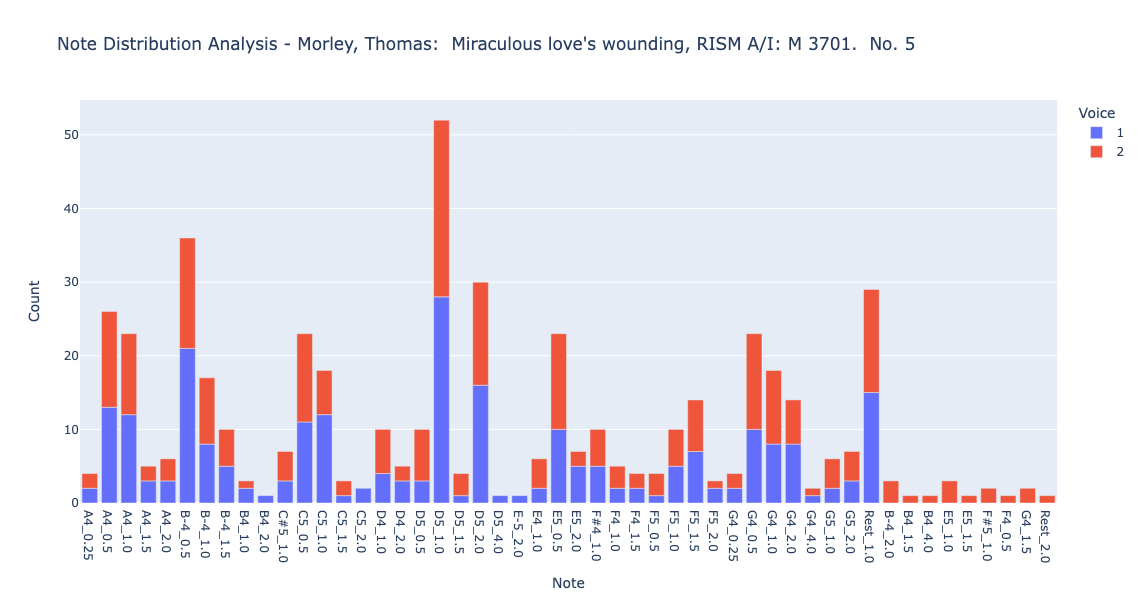

In [9]:
# Create the bar chart
df = note_counts

fig = px.bar(
    df,
    x='Note',
    y='Count',
    color='Voice',
    title=f"Note Distribution Analysis - {piece.metadata['composer']}:  {piece.metadata['title']} ",
    width=800,
    height=600,

    # note that the pitch order is set earlier in our NB!
    category_orders={'Note': pitch_order}
)

fig.show()

## 2.4 Visualize as Radar Plot

In [10]:
# get notes
notes = piece.notes()
notes_numbered = piece.numberParts(notes)
notes_numbered['Composer'] = piece.metadata['composer']
notes_numbered['Title'] = piece.metadata['title']


# melt (we don't need measures and offsets!)
selected_df = notes_numbered
# for melting the data, we will set up value and id variables
value_vars= ['1', '2']
id_vars = [col for col in selected_df.columns if col not in value_vars]

# now melt
selected_df_melted = pd.melt(selected_df, value_vars=value_vars, id_vars=id_vars)
selected_df_melted.rename(columns={'variable': 'Voice', 'value': 'Note'}, inplace=True)
selected_df_melted

# # Option to remove rests
df_clean = selected_df_melted[selected_df_melted['Note'] != 'Rest']


# Count notes by Composer Title Note (but NOT voice)
note_counts = selected_df_melted.groupby(['Composer', 'Title', 'Note', ]).size().reset_index(name='Count')

# remove octave designation
note_counts['Note'] = note_counts['Note'].str.replace(r'\d+', '', regex=True)

# Function to standardize note names
def standardize_note(note):
   
    if '-' in note:
        return note.replace('-', 'b')
    return note

note_counts['Note'] = note_counts['Note'].apply(standardize_note)

# now let's scale the counts relative to the total number of notes in the piece
total_notes = note_counts['Count'].sum()
note_counts['Scaled_Count'] = note_counts['Count']/total_notes
note_counts.head()

,Composer,Title,Note,Count,Scaled_Count
0,"Morley, Thomas","Miraculous love's wounding, RISM A/I: M 3701. ...",A,64,0.127745
1,"Morley, Thomas","Miraculous love's wounding, RISM A/I: M 3701. ...",Bb,66,0.131737
2,"Morley, Thomas","Miraculous love's wounding, RISM A/I: M 3701. ...",B,6,0.011976
3,"Morley, Thomas","Miraculous love's wounding, RISM A/I: M 3701. ...",C#,7,0.013972
4,"Morley, Thomas","Miraculous love's wounding, RISM A/I: M 3701. ...",C,46,0.091816


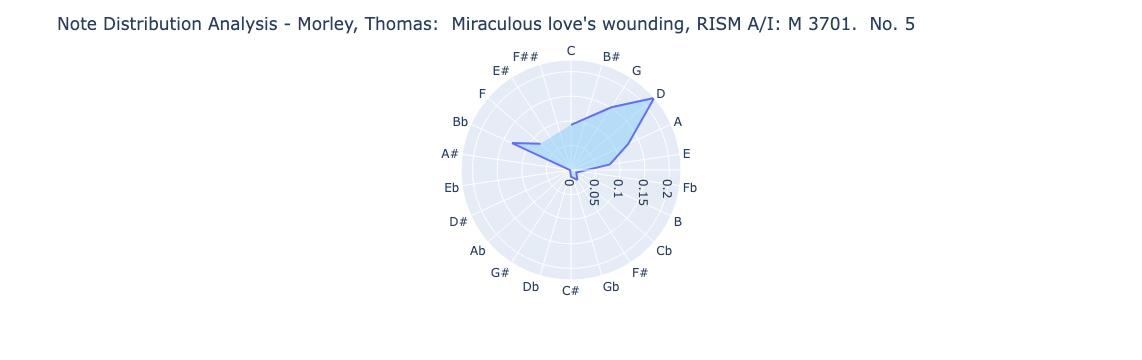

In [11]:
df = note_counts.copy()
counted_notes_sorted = df.groupby('Note')['Scaled_Count'].sum().reset_index()

# sort to match pitch_class_order so the line is drawn in the correct sequence
counted_notes_sorted['Note'] = pd.Categorical(counted_notes_sorted['Note'], 
                                               categories=fifths, 
                                               ordered=True)
counted_notes_sorted = counted_notes_sorted.sort_values('Note').reset_index(drop=True)

# radar pitch order:  'fifths' or 'chromatic'
pitch_class_order = fifths


fig = px.line_polar(
    counted_notes_sorted, 
    r='Scaled_Count',                           
    theta='Note',                              
    line_close=True,
    color='Title' if 'Title' in counted_notes_sorted.columns else None,
    category_orders={'Note': pitch_class_order}
)
fig.update_traces(fill='toself', fillcolor='rgba(135, 206, 250, 0.5)')
fig.update_layout(title=f"Note Distribution Analysis - {piece.metadata['composer']}:  {piece.metadata['title']}")
fig.show()

## 2.4 Try the same with Melodic and Harmonic Intervals


### Melodic

`mel = piece.melodic(kind = 'd', directed=True, compound=True)`

This will return all the melodic 'intervals' in the piece. You can select the type of interval with the `kind` parameter:  

- 'd' = diatonic (in which major and minor thirds will simply be '3') 
- 'c' = chromatic (in which we count every half step between successive notes, in this case a C-G will be '7'
- 'q' = with quality (in which major thirds will be M3 and minor thirds will be m3, for example)

Learn more at via the [tutorial](https://github.com/HCDigitalScholarship/intervals/blob/main/tutorial/06_Melodic_Intervals.md)

### Harmonic

`har = piece.harmonic(kind = 'd', directed=True, compound=True)`
This will return all the melodic 'intervals' in the piece. You can select the type of interval with the `kind` parameter:  

- 'd' = diatonic (in which major and minor thirds will simply be '3') 
- 'c' = chromatic (in which we count every half step between successive notes, in this case a C-G will be '7'
- 'q' = with quality (in which major thirds will be M3 and minor thirds will be m3, for example)

Learn more at via the [tutorial](https://github.com/HCDigitalScholarship/intervals/blob/main/tutorial/07_Harmonic_Intervals.md)
  

Then renumber parts and add measure numbers as needed!

```python
mel = piece.melodic(kind = 'd', directed=True, compound=True)
mel_numbered = piece.numberParts(mel)
mel_numbered_measures = piece.detailIndex(mel_numbered, offset=False, progress=True).reset_index()
mel_numbered_measures['Composer'] = piece.metadata['composer']
mel_numbered_measures['Title'] = piece.metadata['title']
```



In [12]:
#  melodic intervals

# here we decide on 'how' the intervals will be reported
mel = piece.melodic(kind = 'd', directed=True, compound=True)

# numbering the parts to make things simpler
mel_numbered = piece.numberParts(mel)

# and the detailed index to show measure, beat, progress
mel_numbered_measures = piece.detailIndex(mel_numbered, offset=False, progress=True).reset_index()

# add the metadata about composer and title
mel_numbered_measures['Composer'] = piece.metadata['composer']
mel_numbered_measures['Title'] = piece.metadata['title']
mel_numbered_measures

,Measure,Beat,Progress,1,2,Composer,Title
0,1.0,1.00,0.000000,NaN,Rest,"Morley, Thomas","Miraculous love's wounding, RISM A/I: M 3701. ..."
1,1.0,3.00,0.007576,3,NaN,"Morley, Thomas","Miraculous love's wounding, RISM A/I: M 3701. ..."
2,1.0,4.50,0.013258,2,NaN,"Morley, Thomas","Miraculous love's wounding, RISM A/I: M 3701. ..."
3,2.0,1.00,0.015152,2,3,"Morley, Thomas","Miraculous love's wounding, RISM A/I: M 3701. ..."
4,2.0,2.50,0.020833,NaN,2,"Morley, Thomas","Miraculous love's wounding, RISM A/I: M 3701. ..."
...,...,...,...,...,...,...,...
303,66.0,2.50,0.990530,NaN,-2,"Morley, Thomas","Miraculous love's wounding, RISM A/I: M 3701. ..."
304,66.0,2.75,0.991477,NaN,-2,"Morley, Thomas","Miraculous love's wounding, RISM A/I: M 3701. ..."
305,66.0,3.00,0.992424,NaN,2,"Morley, Thomas","Miraculous love's wounding, RISM A/I: M 3701. ..."
306,66.0,4.00,0.996212,-2,NaN,"Morley, Thomas","Miraculous love's wounding, RISM A/I: M 3701. ..."


## 2.5 Bar Chart of Melodic Intervals

In [13]:
# for melting the data, we will set up value and id variables
value_vars= ['1', '2']
id_vars = [col for col in mel_numbered_measures.columns if col not in value_vars]

# now melt
mel_numbered_measures_melted = pd.melt(mel_numbered_measures, value_vars=value_vars, id_vars=id_vars)
mel_numbered_measures_melted.rename(columns={'variable': 'Voice', 'value': 'Interval'}, inplace=True)
mel_numbered_measures_melted


# Count notes by Composer Title Note and Voice
mel_counts = mel_numbered_measures_melted.groupby(['Composer', 'Title', 'Interval', 'Voice']).size().reset_index(name='Count')
mel_counts.head()


,Composer,Title,Interval,Voice,Count
0,"Morley, Thomas","Miraculous love's wounding, RISM A/I: M 3701. ...",-2,1,83
1,"Morley, Thomas","Miraculous love's wounding, RISM A/I: M 3701. ...",-2,2,81
2,"Morley, Thomas","Miraculous love's wounding, RISM A/I: M 3701. ...",-3,1,10
3,"Morley, Thomas","Miraculous love's wounding, RISM A/I: M 3701. ...",-3,2,14
4,"Morley, Thomas","Miraculous love's wounding, RISM A/I: M 3701. ...",-4,1,9


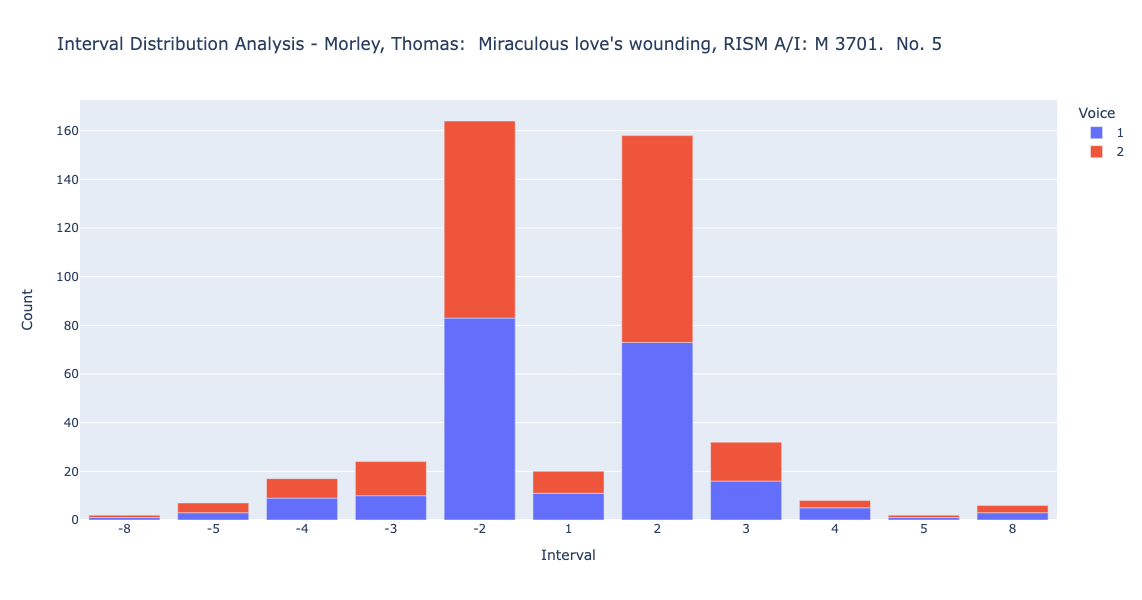

In [14]:
# Create the bar chart
df = mel_counts.copy()

# remove rests
df_no_rests = df[df['Interval'] !=  'Rest']

unique_intervals = df_no_rests['Interval'].unique()

# unique_intervals_no_rest = [interval for interval in unique_intervals if interval != "Rest"]

# sorting function
def sort_integer_strings_explicit(string_array):
    """
    Explicit method: separate negatives and positives, then sort each group
    """
    negatives = [s for s in string_array if int(s) < 0]
    positives = [s for s in string_array if int(s) >= 0]
    
    # Sort negatives in descending order (highest negative first: -1, -2, -3...)
    negatives.sort(key=lambda x: int(x), reverse=False)
    
    # Sort positives in ascending order (lowest positive first: 0, 1, 2, 3...)
    positives.sort(key=lambda x: int(x))
    
    return negatives + positives

interval_order = sort_integer_strings_explicit(unique_intervals)

fig = px.bar(
    df_no_rests,
    x='Interval',
    y='Count',
    color='Voice',
    title=f"Interval Distribution Analysis - {piece.metadata['composer']}:  {piece.metadata['title']} ",
    width=800,
    height=600,

    # note that the pitch order is set earlier in our NB!
    category_orders={'Interval': interval_order}
)

fig.show()

In [15]:
# you could continue to experiment with piece.harmonic, or piece.ngrams

In [16]:
mel = piece.melodic(kind='d')
har = piece.harmonic(kind='d', directed=False)


ng = piece.ngrams(df=har, other=mel, n=4)
det = piece.detailIndex(df=ng).reset_index()
det.head(10)

,Measure,Beat,Part-2_Soprano
0,1.0,3.0,"3_Held, 4_3, 3_2, 2"
1,3.0,2.0,"10_Held, 11_-2, 3_-2, 2"
2,3.0,3.0,"11_-2, 3_-2, 2_Held, 3"
3,3.0,4.0,"3_-2, 2_Held, 3_-2, 1"
4,4.0,1.0,"2_Held, 3_-2, 1_Held, 1"
5,5.0,2.0,"10_Held, 9_3, 6_2, 5"
6,5.0,2.5,"9_3, 6_2, 5_2, 3"
7,5.0,3.0,"6_2, 5_2, 3_-3, 6"
8,5.0,4.5,"5_2, 3_-3, 6_Held, 5"
9,6.0,1.0,"3_-3, 6_Held, 5_2, 3"


## 2.6 Heat Map of Ngrams

- Learn about ngrams via the [tutorial](https://github.com/HCDigitalScholarship/intervals/blob/main/tutorial/09_Ngrams_Heat_Maps.md)!

The function takes in various arguments:
- combine_unisons_choice=False:  whether to combine unisons
- kind_choice='d' :  d for diatonic, etc
- directed=True:  directed intervals or not
- compound=True:  compound intervals or not
- length_choice=4:  length of ngram
- include_count=True:  include chart of count of ngrams
- entries_only=True:  limit the ngrams to 'entries' (events after rests or breaks)

In [17]:
# function for ngram heatmap:  do not edit!

def ngram_heatmap(piece, 
                  combine_unisons_choice=False, 
                  kind_choice='d', 
                  directed=True, 
                  compound=True, 
                  length_choice=6, 
                  include_count=False, 
                  entries_only=True):
    # find ngrams
    nr = piece.notes(combineUnisons = combine_unisons_choice)
    mel = piece.melodic(df = nr, 
                        kind = kind_choice,
                        directed = directed,
                        compound = compound,
                        end = False)
    
    # this is for entries only
    if entries_only == True:    
        # pass the following ngrams to the plot below as first df
        entry_ngrams = piece.entries(df = mel, 
                                    n = length_choice, 
                                    thematic = True, 
                                    anywhere = True,
                                    exclude = ['Rest'])
        # pass the ngram durations below to the plot as second df
        entry_ngrams_duration = piece.durations(df = mel, 
                                            n =length_choice, 
                                            mask_df = entry_ngrams)
        # make the heatmap
        chart = viz.plot_ngrams_heatmap(entry_ngrams, 
                                         entry_ngrams_duration, 
                                         selected_patterns=[], 
                                         voices=[],  
                                         includeCount=include_count)
        
        return chart
    
    # this is for ALL mel ngrams (if entries is False in form)
    else:
        mel_ngrams = piece.ngrams(df = mel, n = length_choice, exclude = ['Rest'])
        mel_ngrams_duration = piece.durations(df = mel, 
                                          n =length_choice)
        
        chart = viz.plot_ngrams_heatmap(mel_ngrams, 
                                         mel_ngrams_duration, 
                                         selected_patterns=[], 
                                         voices=[], 
                                         includeCount=include_count)
        
        # # mel_ngrams_detail = piece.detailIndex(mel_ngrams, offset = False)  
        return chart

In [18]:

# duration of the ngrams (so we can see how long they last for our chart!)
nr = piece.notes()
mel = piece.melodic(df = nr, 
                        end = False)
mel_ngrams = piece.ngrams(df = mel, n=4)
mel_ngrams_duration = piece.durations(df = mel, n=4)

mel_ngrams_duration

,Soprano,Part-2
0.0,6.0,6.00
2.0,5.0,6.00
3.5,4.5,NaN
4.0,5.0,5.00
5.5,NaN,5.50
...,...,...
258.0,3.0,3.50
258.5,4.5,NaN
259.0,9.0,2.75
260.5,NaN,1.50


In [19]:
ngram_heatmap(piece)

alt.Chart(...)

## 2.7  Contrapuntal Ngrams

- These are ngrams that combine both harmonic and melodic motion to make a 'contrapuntal' pattern
- These are perfect for finding things like cadences (which follow very specific formulas), or repeating complexes of voices
  

In [20]:
# melodic and harmonic dfs
mel = piece.melodic(kind='d')
har = piece.harmonic(kind='d', directed=False)

# number the parts
mel = piece.numberParts(mel)
har = piece.numberParts(har)

# now the ngrams by combining these
ng = piece.ngrams(df=har, other=mel, n=4)

# add details of measure, beats, and progress

ng_det = piece.detailIndex(ng, progress=True).reset_index()

# add metadata
ng_det['composer'] = piece.metadata['composer']
ng_det['title'] = piece.metadata['title']
ng_det.head(10)

,Measure,Beat,Progress,2_1,composer,title
0,1.0,3.0,0.007576,"3_Held, 4_3, 3_2, 2","Morley, Thomas","Miraculous love's wounding, RISM A/I: M 3701. ..."
1,3.0,2.0,0.034091,"10_Held, 11_-2, 3_-2, 2","Morley, Thomas","Miraculous love's wounding, RISM A/I: M 3701. ..."
2,3.0,3.0,0.037879,"11_-2, 3_-2, 2_Held, 3","Morley, Thomas","Miraculous love's wounding, RISM A/I: M 3701. ..."
3,3.0,4.0,0.041667,"3_-2, 2_Held, 3_-2, 1","Morley, Thomas","Miraculous love's wounding, RISM A/I: M 3701. ..."
4,4.0,1.0,0.045455,"2_Held, 3_-2, 1_Held, 1","Morley, Thomas","Miraculous love's wounding, RISM A/I: M 3701. ..."
5,5.0,2.0,0.064394,"10_Held, 9_3, 6_2, 5","Morley, Thomas","Miraculous love's wounding, RISM A/I: M 3701. ..."
6,5.0,2.5,0.066288,"9_3, 6_2, 5_2, 3","Morley, Thomas","Miraculous love's wounding, RISM A/I: M 3701. ..."
7,5.0,3.0,0.068182,"6_2, 5_2, 3_-3, 6","Morley, Thomas","Miraculous love's wounding, RISM A/I: M 3701. ..."
8,5.0,4.5,0.073864,"5_2, 3_-3, 6_Held, 5","Morley, Thomas","Miraculous love's wounding, RISM A/I: M 3701. ..."
9,6.0,1.0,0.075758,"3_-3, 6_Held, 5_2, 3","Morley, Thomas","Miraculous love's wounding, RISM A/I: M 3701. ..."


In [21]:
# for pieces in Renaissance style, we can use these to find cadences
cadences = piece.cadences()
cadences


,CadType,LeadingTones,CVFs,Low,RelLow,Tone,RelTone,TSig,Measure,Beat,Sounding,Progress,SinceLast,ToNext
Last,,,,,,,,,,,,,,
14.0,Clausula Vera,1,CT,D5,P5,D,-P4,4/4,4.0,3.0,2.0,0.053030,14.0,26.0
40.0,Evaded Clausula Vera,1,Ct,G4,P1,G,-P1,4/4,11.0,1.0,2.0,0.151515,26.0,14.0
54.0,Clausula Vera,1,TC,D5,P5,D,-P4,4/4,14.0,3.0,2.0,0.204545,14.0,26.0
80.0,Evaded Clausula Vera,1,tC,G4,P1,G,-P1,4/4,21.0,1.0,2.0,0.303030,26.0,30.0
110.0,Abandoned Clausula Vera,1,zC,D5,P5,D,-P4,4/4,28.0,3.0,1.0,0.416667,30.0,10.0
120.0,Clausula Vera,1,TC,B-4,m3,B-,m3,4/4,31.0,1.0,2.0,0.454545,10.0,44.0
164.0,Clausula Vera,1,TC,D5,P5,D,-P4,4/4,42.0,1.0,2.0,0.621212,44.0,20.0
184.0,Clausula Vera,1,TC,G4,P1,G,-P1,4/4,47.0,1.0,2.0,0.696970,20.0,14.0
198.0,Clausula Vera,1,TC,D5,P5,D,-P4,4/4,50.0,3.0,2.0,0.750000,14.0,26.0


# 3.0 Build a Corpus

Here we obtain the MEI files from our work.

Note that you can use wildcards to limit the corpus to certain files.

```python
all_bach = glob.glob('MEI/Bach*')
all_bach = sorted(all_bach)
```

             
Now Load The List as a CRIM Intervals Corpus           

`corpus = CorpusBase(all_bach)`

In [22]:
# for example
all_bach = glob.glob('MEI/Bach*')
all_bach = sorted(all_bach)
corpus = CorpusBase(all_bach)

mei.base: WARNING: Importing <tupletSpan> without @startid and @endid or @plist is not yet supported.
mei.base: WARNING: Importing <tupletSpan> without @startid and @endid or @plist is not yet supported.


## 3.1 Applying CRIM Intervals Functions to Each Piece in a Corpus

Here we apply the _same_ function to each piece in a corpus and then return a combined df that represents our results.  With this we can filter, group, as well as make charts and graphs to show _shared_ patterns across our corpus.

To learn more about how this works, see the [Corpus Tutorial](https://github.com/HCDigitalScholarship/intervals/blob/main/tutorial/01_Introduction_and_Corpus.md#batch-methods-for-a-corpus-of-pieces) from the CRIM Intervals documentation.


Fortunately for you, we have also created a special set of `corpus tools` that make easy work of all of this.  Learn about them via the [relevant tutorial](https://github.com/HCDigitalScholarship/intervals/blob/main/tutorial/21_Corpus_Tools.md).  

All you need to do:

```python
# define your corpus
all_bach = glob.glob('Updates/Bach*')
all_bach = sorted(all_bach)
corpus = CorpusBase(all_bach)

# pass it to the corpus_tool, note that the arguments determine the settings

corpus_notes(corpus, combine_unisons_choice=True, combine_rests_choice=False)
```


Here are all the corpus tools, in brief:


- corpus_notes
- corpus_note_scaled
- corpus_note_durs
- corpus_mel
- corpus_har
- corpus_contrapuntal_ngrams
- corpus_melodic_ngrams
- corpus_melodic_durational_ratios_ngrams
- corpus_harmonic_ngrams
- corpus_sonority_ngrams
- corpus_cadences
- corpus_presentation_types

## 3.2  Corpus Notes

In [23]:
# define your corpus
all_bach = glob.glob('MEI/Bach*')
all_bach = sorted(all_bach)
corpus = CorpusBase(all_bach)

# pass it to the corpus_tool, note that the arguments determine the settings

corpus_note_df = corpus_notes(corpus, combine_unisons_choice=True, combine_rests_choice=False)
corpus_note_df

mei.base: WARNING: Importing <tupletSpan> without @startid and @endid or @plist is not yet supported.
mei.base: WARNING: Importing <tupletSpan> without @startid and @endid or @plist is not yet supported.


,Composer,Title,Date,1,2
0.0,"Bach, Johann Sebastian","Invention No. 1 in C major, BWV 772",None,Rest,Rest
0.25,"Bach, Johann Sebastian","Invention No. 1 in C major, BWV 772",None,C4,NaN
0.5,"Bach, Johann Sebastian","Invention No. 1 in C major, BWV 772",None,D4,NaN
0.75,"Bach, Johann Sebastian","Invention No. 1 in C major, BWV 772",None,E4,NaN
1.0,"Bach, Johann Sebastian","Invention No. 1 in C major, BWV 772",None,F4,NaN
...,...,...,...,...,...
82.75,"Bach, Johann Sebastian","Invention No. 15 in B minor, BWV 786",None,D5,G3
83.0,"Bach, Johann Sebastian","Invention No. 15 in B minor, BWV 786",None,A#4,F#3
83.5,"Bach, Johann Sebastian","Invention No. 15 in B minor, BWV 786",None,NaN,F#2
83.75,"Bach, Johann Sebastian","Invention No. 15 in B minor, BWV 786",None,B4,NaN


## 3.3 Visualizing Results for Corpus

### 3.3.1 A Bar Chart of Notes for a Corpus

Here we look at the distribution of notes, breaking things down by voice-part (1 is the top part, 2 is the bottom one)

In [24]:

# run function and create chart
corpus_note_df = corpus_notes(corpus, combine_unisons_choice=True, combine_rests_choice=False)

value_vars= ['1', '2']
id_vars = [col for col in corpus_note_df.columns if col not in value_vars]
corpus_note_df_melted = pd.melt(corpus_note_df, value_vars=value_vars, id_vars=id_vars)
corpus_note_df_melted.rename(columns={'variable': 'Voice', 'value': 'Note'}, inplace=True)
corpus_note_df_melted
# Clean data - remove Rest and NaN values
df_clean = corpus_note_df_melted[
    (corpus_note_df_melted['Note'].notna()) & 
    (corpus_note_df_melted['Note'] != 'Rest')
].copy()

# Count notes by Composer Title Note and Voice
corpus_note_counts = df_clean.groupby(['Composer', 'Title', 'Note', 'Voice']).size().reset_index(name='Count')
corpus_note_counts


,Composer,Title,Note,Voice,Count
0,"Bach, Johann Sebastian","Invention No. 1 in C major, BWV 772",A2,2,3
1,"Bach, Johann Sebastian","Invention No. 1 in C major, BWV 772",A3,2,21
2,"Bach, Johann Sebastian","Invention No. 1 in C major, BWV 772",A4,1,22
3,"Bach, Johann Sebastian","Invention No. 1 in C major, BWV 772",A4,2,5
4,"Bach, Johann Sebastian","Invention No. 1 in C major, BWV 772",A5,1,10
...,...,...,...,...,...
704,"Bach, Johann Sebastian","Invention No. 9 in F minor, BWV 780",G2,2,4
705,"Bach, Johann Sebastian","Invention No. 9 in F minor, BWV 780",G3,2,36
706,"Bach, Johann Sebastian","Invention No. 9 in F minor, BWV 780",G4,1,20
707,"Bach, Johann Sebastian","Invention No. 9 in F minor, BWV 780",G4,2,4


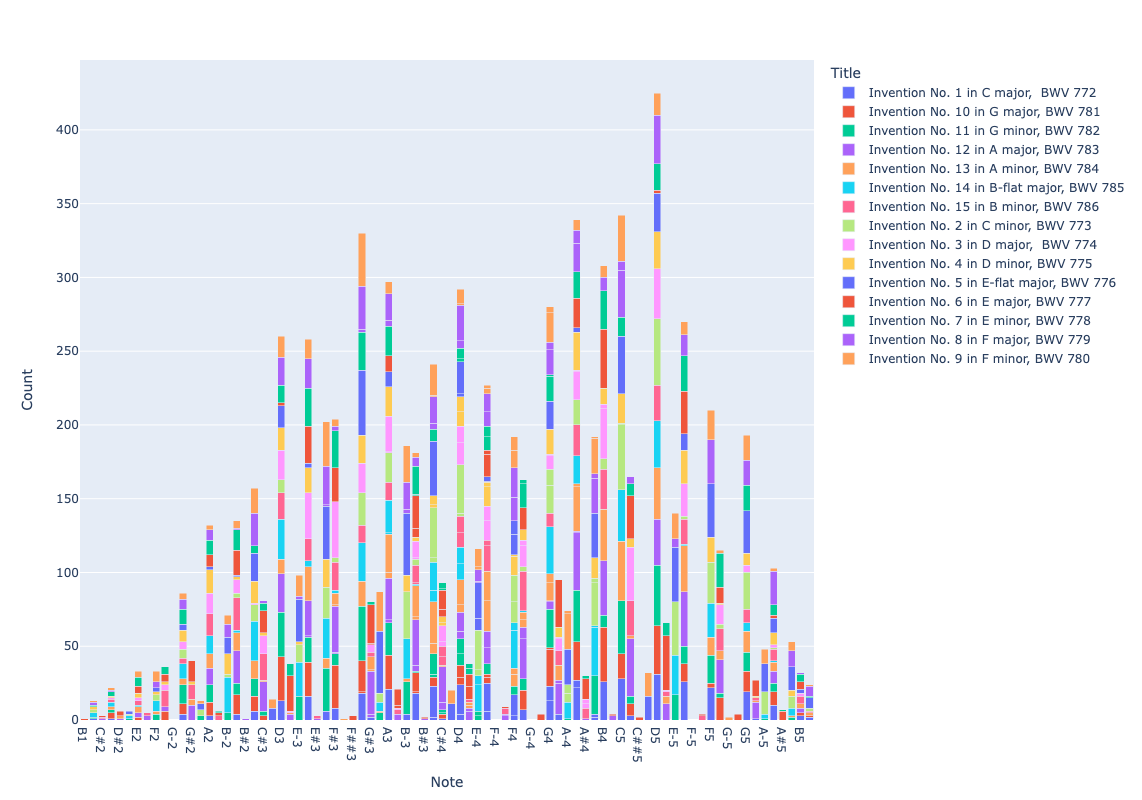

In [25]:
# Create the bar chart
fig = px.bar(
    corpus_note_counts,
    x='Note',
    y='Count',
    color='Title',
    height=800,
    width=1000,
    barmode='stack',
    # note that the pitch order is set earlier in our NB!
    category_orders={'Note': pitch_order}
)

fig.show()

### 3.3.2 As Radar Plot

Here we display the notes on a radar plot.  But now the colors correspond to the title of each piece.

Of course we could set the color to correspond to some other feature in the df, like composer.  

In [26]:

# # Option to remove rests
corpus_clean = corpus_note_counts[corpus_note_counts['Note'] != 'Rest']

# remove octave designation
corpus_clean['Note'] = corpus_clean['Note'].str.replace(r'\d+', '', regex=True)

# # Function to standardize note names
def standardize_note(note):
   
    if '-' in note:
        return note.replace('-', 'b')
    return note

corpus_clean['Note'] = corpus_clean['Note'].apply(standardize_note)

# Count notes by Composer Title Note (but NOT voice)
corpus_note_counts_grouped = corpus_clean.groupby(['Composer', 'Title', 'Note', ]).size().reset_index(name='Count')


# now let's scale the counts relative to the total number of notes in the piece
total_notes = corpus_note_counts_grouped['Count'].sum()
corpus_note_counts_grouped['Scaled_Count'] = corpus_note_counts_grouped['Count']/total_notes
corpus_note_counts_grouped.head(10)

,Composer,Title,Note,Count,Scaled_Count
0,"Bach, Johann Sebastian","Invention No. 1 in C major, BWV 772",A,5,0.007052
1,"Bach, Johann Sebastian","Invention No. 1 in C major, BWV 772",B,4,0.005642
2,"Bach, Johann Sebastian","Invention No. 1 in C major, BWV 772",Bb,3,0.004231
3,"Bach, Johann Sebastian","Invention No. 1 in C major, BWV 772",C,6,0.008463
4,"Bach, Johann Sebastian","Invention No. 1 in C major, BWV 772",C#,2,0.002821
5,"Bach, Johann Sebastian","Invention No. 1 in C major, BWV 772",D,5,0.007052
6,"Bach, Johann Sebastian","Invention No. 1 in C major, BWV 772",E,4,0.005642
7,"Bach, Johann Sebastian","Invention No. 1 in C major, BWV 772",F,4,0.005642
8,"Bach, Johann Sebastian","Invention No. 1 in C major, BWV 772",F#,2,0.002821
9,"Bach, Johann Sebastian","Invention No. 1 in C major, BWV 772",G,5,0.007052


In [27]:
# categorical sorting:  'fifths' or 'chromatic'
pitch_class_order = fifths

corpus_note_counts_grouped['Note'] = pd.Categorical(corpus_note_counts_grouped['Note'], categories=pitch_class_order, ordered=True)
corpus_note_counts_grouped_sorted = corpus_note_counts_grouped.sort_values('Note').reset_index(drop=True)
corpus_note_counts_grouped_sorted

,Composer,Title,Note,Count,Scaled_Count
0,"Bach, Johann Sebastian","Invention No. 2 in C minor, BWV 773",C,7,0.009873
1,"Bach, Johann Sebastian","Invention No. 14 in B-flat major, BWV 785",C,5,0.007052
2,"Bach, Johann Sebastian","Invention No. 9 in F minor, BWV 780",C,6,0.008463
3,"Bach, Johann Sebastian","Invention No. 1 in C major, BWV 772",C,6,0.008463
4,"Bach, Johann Sebastian","Invention No. 3 in D major, BWV 774",C,1,0.001410
...,...,...,...,...,...
168,"Bach, Johann Sebastian","Invention No. 6 in E major, BWV 777",E#,2,0.002821
169,"Bach, Johann Sebastian","Invention No. 12 in A major, BWV 783",E#,4,0.005642
170,"Bach, Johann Sebastian","Invention No. 15 in B minor, BWV 786",E#,4,0.005642
171,"Bach, Johann Sebastian","Invention No. 6 in E major, BWV 777",F##,3,0.004231


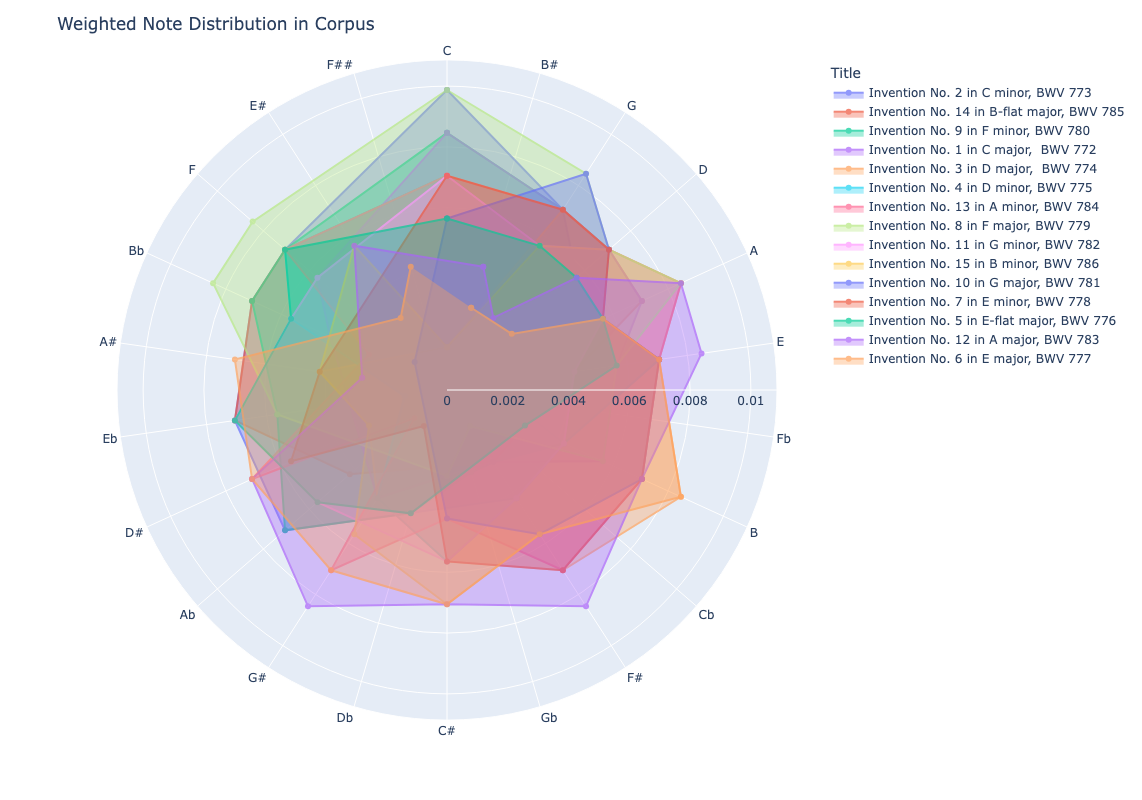

In [28]:

titles = corpus_note_counts_grouped_sorted['Title'].unique()
fig = px.line_polar(
    corpus_note_counts_grouped_sorted,
    r='Scaled_Count',
    theta='Note',
    color='Title',
    line_close=True,
    range_r=[0, corpus_note_counts_grouped_sorted['Scaled_Count'].max() * 1.1],
    markers=True,
    height=800,
    width=800,
    category_orders={'Note': fifths}
)
fig.update_traces(fill='toself', 
                mode='markers+lines',
                opacity=.7)
fig.update_layout(
    showlegend=True,
    legend=dict(
        title='Title',
        orientation="v"
    ),
    title = 'Weighted Note Distribution in Corpus')
fig.show()

### 3.3.3. Barchart of Melodic Intervals

In [29]:
mel = corpus_mel(corpus, kind_choice='d', compound_choice=False)
# Melt the dataframe to combine columns '1' and '2' into one
mel_melted = mel.melt(
    id_vars=['Composer', 'Title', 'Date'], 
    value_vars=['1', '2'], 
    var_name='Voice', 
    value_name='Interval'
)

# Drop NaN values
mel_melted = mel_melted.dropna(subset=['Interval'])

# Count intervals by Title (and optionally Voice)
mel_counts = mel_melted.groupby(['Title', 'Interval']).size().reset_index(name='Count')

# Get unique intervals and convert to integers for sorting
unique_intervals = mel_counts['Interval'].dropna().unique()

# Sort: negatives descending (most negative first), then positives ascending
def interval_sort_key(x):
    try:
        val = int(x)
        # Negatives get sorted by their value (ascending, so -8 comes before -7)
        # Positives get sorted after all negatives
        if val < 0:
            return (0, val)  # First group, sort by value
        else:
            return (1, val)  # Second group, sort by value
    except:
        return (2, 0)  # Put non-numeric (like 'Rest') at the end

sorted_intervals = sorted(unique_intervals, key=interval_sort_key)

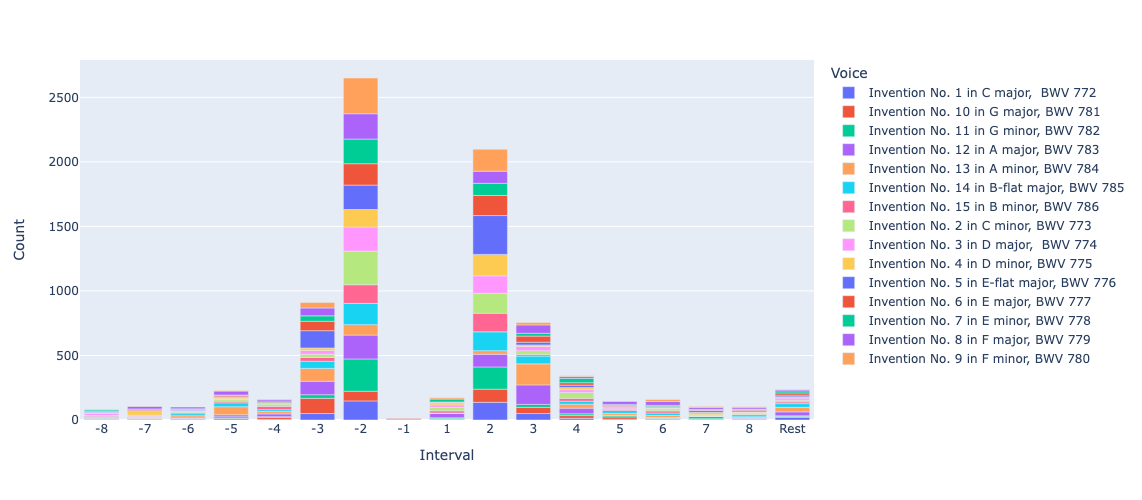

In [30]:

chart_title = "Distribution of Melodic Intervals in Corpus"

#create barchart
fig = px.bar(
    mel_counts,
    x='Interval',
    y='Count',
    color='Title',
    category_orders={'Interval': sorted_intervals}
)
fig.update_layout(xaxis_title="Interval", 
                    yaxis_title="Count",
                    legend_title='Voice',
                       height=500,
                       width=750)

fig.show()

## 4.0 Network of Pieces based on Shared Melodic Ngrams


Here we build a **network** of pieces:  each time two pieces share a melodic ngram, they get an edge.

- The results are often quite dense, so we include a 'minimum threshold' value:  unless two pieces have at least 'n' edges, they are excluded from the network.

- A 'thickness' adjustment also scales the width of the edges so that the results are easier to interpret.

```python
# the ngram conditions
n=4
combineUnisons=False
kind='c'
thematic = True
anywhere = False
threshold_for_shared_ngrams = 30
thickness_adjust = 5
```

In [31]:
# Network Function--Do Not Edit!
def ng_network(data, 
               threshold_for_shared_ngrams=5, 
               thickness_adjust=5, 
               network_name='my_network.html'):

    # and now, a network in which the nodes are the pieces and edges represent the ngrams they share.  
    # the thickness of the edges varies with the number of shared ngrams
    # the colors distinguish 'communities' of pieces that are highly related

    df = pd.DataFrame(data)
    df = df.reset_index()
    df.drop('level_1', axis=1, inplace=True)
    df = df.rename(columns={0: 'ngram'})

    #define the function to convert tuples to strings
    def convertTuple(tup):
        out = ""
        if isinstance(tup, tuple):
            out = '_'.join(tup)
        return out  
    # clean the tuples
    df['ngram'] = df['ngram'].apply(convertTuple)

    # Group by 'ngram' and extract a list of unique titles for each group
    grouped_titles = df.groupby('ngram')['title'].unique().reset_index(name='titles')

    # Generate all pairs of titles for each group
    all_pairs = []
    for _, row in grouped_titles.iterrows():
        pairs = list(combinations(row['titles'], 2))
        all_pairs.append((row['ngram'], pairs))

    # Create a new DataFrame with the results
    result_df = pd.DataFrame(all_pairs, columns=['ngram', 'title_pairs'])
    # remove the empty pairs
    df_filtered = result_df[result_df['title_pairs'].apply(len) > 0]

    # explode the complicated lists of tuples, effectively 'tyding' the data
    exploded_df = df_filtered.explode('title_pairs')

    # get the counts of each pair, which provides the basis of the weights
    pair_counts = exploded_df['title_pairs'].value_counts()

    # limit to high scoring pairs (>3)
    pair_counts = pair_counts[pair_counts >= threshold_for_shared_ngrams]

    # Adding Louvain Communities
    def add_communities(G):
        G = deepcopy(G)
        partition = community_louvain.best_partition(G)
        nx.set_node_attributes(G, partition, "group")
        return G

    # Create an empty NetworkX graph
    G = nx.Graph()


    # Add nodes and assign weights to edges
    for pair, count in pair_counts.items():
        # Directly unpacking the tuple into node1 and node2
        node1, node2 = pair
        # Adding nodes if they don't exist already
        if node1 not in G.nodes:
            G.add_node(node1)
        if node2 not in G.nodes:
            G.add_node(node2)
        # Adding edge with weight
        G.add_edge(node1, node2, weight=count)

    # Adjusting edge thickness based on weights
    for edge in G.edges(data=True):
        edge[2]['width'] = edge[2]['weight']/thickness_adjust

    G = add_communities(G)

    # set display parameters
    ngram_map = Network(notebook=True,
                       width="800",
                              height="800",
                              bgcolor="black", 
                              font_color="white")

    # Set the physics layout of the network
    ngram_map.set_options("""
    {
    "physics": {
    "enabled": true,
    "forceAtlas2Based": {
        "springLength": 1
    },
    "solver": "forceAtlas2Based"
    }
    }
    """)

    ngram_map.from_nx(G)
    return ngram_map.show(network_name)
    

    

### Make the Network

NOTE:  you will need to find the HTML file in your folder and open it in a new browser tab!

In [32]:


# the ngram conditions
n=4
combineUnisons=False
kind='c'
thematic = True
anywhere = False
threshold_for_shared_ngrams = 2
thickness_adjust = 5
network_name = 'melodic_ngram_network.html'


# now we build a list of all of the ngrams in each piece
list_series = []
for item in all_bach:
    piece = importScore(item)
    title = piece.metadata['composer'] + ": " + piece.metadata['title']
    # find entries for model
    nr = piece.notes(combineUnisons=combineUnisons)
    nr = piece.numberParts(df=nr)
    mel = piece.melodic(df=nr, kind=kind, compound=False, unit=0, end=False)
    mel_ngrams = piece.ngrams(df=mel, n=n, exclude=['Rest'])
    mel_ngrams.fillna('')
    mel_ngrams['title'] = title
    mel_ngrams.set_index(['title'], inplace=True)
    # Set the new column as the index
    mel_stacked_ngs = mel_ngrams.stack()
    list_series.append(mel_stacked_ngs)

ngs = pd.concat(list_series)

print("Network of Melodic Ngrams")
ng_network(ngs, threshold_for_shared_ngrams, thickness_adjust, network_name)


mei.base: WARNING: Importing <tupletSpan> without @startid and @endid or @plist is not yet supported.
mei.base: WARNING: Importing <tupletSpan> without @startid and @endid or @plist is not yet supported.


Network of Melodic Ngrams
